# Hybrid models as structural diagnostics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BennettHydroLab/differentiable_modeling_workshop/blob/main/notebooks/applications/05_hybrid_as_diagnostic.ipynb)

The same one-dimensional closure is inserted into runoff generation,
evaporative stress, and routing. Comparing these controlled variants tests
where added flexibility improves held-out behavior and how the conclusion
depends on the evaluation metric.

:::{admonition} Time check: 15 minutes
:class: tip
You will compare closure locations, inspect learned constitutive relations, and
distinguish a useful structural hypothesis from a small score difference.
:::

## Outline

1. Three candidate closures
2. Controlled training protocol
3. Train, validation, and test comparisons
4. Learned functions and limitations


In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import copy
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import nse, summary, set_style, COLORS, ParamMap, MLP
from workshop_utils.data import (
    load_basin, split_by_water_year, BASIN_TEMPERATE, BASIN_LABELS,
)

set_style()
torch.manual_seed(0)

SPINUP = 365
S_REF = 10.0

## 1. Three candidate closures

The HBV-style model receives three alternative one-dimensional closures:

| Slot | Replaced relation | Input-output question |
|---|---|---|
| `soil` | $R=P(S/FC)^\beta$ | recharge fraction versus wetness |
| `et` | $E=\mathrm{PET}\min(S/(LP\,FC),1)$ | evaporative stress versus wetness |
| `route` | $q=KS$ | release fraction versus storage |

Each network produces a bounded correction and starts with a zero output, so
every variant initially matches the same calibrated baseline. A fourth variant
activates all three closures.


In [3]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC"]
LO = torch.tensor([ 50., 1.0, 0.3, 0.05, 0.005, 0.1])
HI = torch.tensor([500., 5.0, 1.0, 0.60, 0.150, 3.0])
pmap = ParamMap(LO, HI)


def logit(p):
    return torch.log(p / (1 - p))


def simulate(P, E, theta, nets=None):
    """HBV-lite with up to three learned closures. nets: {'soil'|'et'|'route': MLP}."""
    nets = nets or {}
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]

    S_soil = torch.full((n,), 50.)
    S_fast = torch.full((n,), 5.)
    S_slow = torch.full((n,), 20.)

    out = []
    for t in range(P.shape[0]):
        wetness = torch.clamp(S_soil / FC, 0., 1.)

        # --- slot 1: runoff generation ---------------------------------------
        base = torch.clamp(wetness, 1e-4, 1 - 1e-4) ** beta
        if "soil" in nets:
            r_frac = torch.sigmoid(logit(base) + nets["soil"](wetness.unsqueeze(-1)).squeeze(-1))
        else:
            r_frac = base
        recharge = P[t] * r_frac

        # --- slot 2: evaporative stress --------------------------------------
        base = torch.clamp(S_soil / (LP * FC), 1e-4, 1 - 1e-4)
        if "et" in nets:
            e_frac = torch.sigmoid(logit(base) + nets["et"](wetness.unsqueeze(-1)).squeeze(-1))
        else:
            e_frac = base
        et = E[t] * e_frac

        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + recharge - perc

        # --- slot 3: storage-discharge ---------------------------------------
        if "route" in nets:
            k = torch.sigmoid(logit(K_fast)
                              + nets["route"]((S_fast / S_REF).unsqueeze(-1)).squeeze(-1))
        else:
            k = K_fast * torch.ones(n)
        q_fast = k * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        out.append(q_fast + q_slow)

    return torch.stack(out)

In [4]:
ds = load_basin(BASIN_TEMPERATE)


def block(test_years):
    return split_by_water_year(ds, train=(1998, 1999), test=test_years, spinup_days=SPINUP)


def arrays(d):
    return tuple(torch.tensor(d[v].values, dtype=torch.float32)
                 for v in ["prcp", "pet", "qobs"])


P,  E,  Q  = arrays(block((2000, 2001))["train"])
Pv, Ev, Qv = arrays(block((2000, 2001))["test"])
Pt, Et, Qt = arrays(block((2002, 2004))["test"])

print(f"{BASIN_LABELS[BASIN_TEMPERATE]}: "
      f"{len(P)} train / {len(Pv)} validation / {len(Pt)} test days")

Cowpasture River, VA (humid temperate): 1095 train / 1096 validation / 1461 test days


## 2. Controlled training protocol

All variants start from the same physical parameters, use zero-initialized
closure outputs, receive the same optimizer and 15 gradient steps, stop on
validation, and are reported on the same test block.


In [5]:
t0 = time.time()
raw_phys = torch.zeros(1, 6, requires_grad=True)
opt = torch.optim.Adam([raw_phys], lr=0.25)
for step in range(40):
    opt.zero_grad()
    loss = -nse(simulate(P, E, pmap(raw_phys))[SPINUP:, 0], Q[SPINUP:])
    loss.backward()
    opt.step()
raw_phys = raw_phys.detach()
theta_phys = pmap(raw_phys)
print(f"physics calibrated in {time.time()-t0:.1f} s, train NSE {-loss.item():.3f}")
print("  " + "  ".join(f"{n}={v:.3f}" for n, v in zip(PARAM_NAMES, theta_phys[0].tolist())))

physics calibrated in 28.2 s, train NSE 0.635
  FC=198.519  beta=4.560  LP=0.897  K_fast=0.322  K_slow=0.028  PERC=1.455


In [6]:
def evaluate(theta, nets=None, data=None):
    P_, E_, Q_ = data
    with torch.no_grad():
        q = simulate(P_, E_, theta, nets)[:, 0]
    return summary(q[SPINUP:], Q_[SPINUP:])


def train_hybrid(slots, steps=15, lr_phi=5e-3, seed=0):
    """Train one configuration. `slots` is a list like ['route'] or ['soil','et']."""
    torch.manual_seed(seed)
    nets = {s: MLP(n_in=1, n_out=1, hidden=16, depth=2) for s in slots}
    for net in nets.values():
        with torch.no_grad():          # start exactly at the calibrated physics
            net.net[-1].weight.zero_()
            net.net[-1].bias.zero_()

    raw = raw_phys.clone().requires_grad_(True)
    phi = [p for net in nets.values() for p in net.parameters()]
    opt = torch.optim.Adam([{"params": [raw], "lr": 0.05},
                            {"params": phi, "lr": lr_phi}])

    best, t0 = (-np.inf, None, 0), time.time()
    for step in range(steps):
        opt.zero_grad()
        loss = -nse(simulate(P, E, pmap(raw), nets)[SPINUP:, 0], Q[SPINUP:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_([raw] + phi, 1.0)
        opt.step()
        v = evaluate(pmap(raw).detach(), nets, (Pv, Ev, Qv))["NSE"]
        if v > best[0]:
            best = (v, (raw.detach().clone(), copy.deepcopy(nets)), step + 1)

    raw_b, nets_b = best[1]
    return {
        "theta": pmap(raw_b), "nets": nets_b,
        "train": float(-loss.item()), "val": best[0], "step": best[2],
        "test": evaluate(pmap(raw_b), nets_b, (Pt, Et, Qt)),
        "seconds": time.time() - t0,
    }

In [7]:
results = {"physics": {
    "theta": theta_phys, "nets": {},
    "train": float(-loss.item()),
    "val": evaluate(theta_phys, None, (Pv, Ev, Qv))["NSE"],
    "step": 40, "seconds": 0.0,
    "test": evaluate(theta_phys, None, (Pt, Et, Qt)),
}}


def run(label, slots):
    """One configuration, in its own cell so no single cell runs over a minute."""
    results[label] = r = train_hybrid(slots)
    print(f"{label:12s}  {r['seconds']:5.1f} s   train {r['train']:.3f}   "
          f"val {r['val']:.3f}   test NSE {r['test']['NSE']:.3f}")


run("soil NN", ["soil"])

soil NN        19.9 s   train 0.639   val 0.527   test NSE 0.591


In [8]:
run("ET NN", ["et"])

ET NN          20.0 s   train 0.643   val 0.540   test NSE 0.582


In [9]:
run("routing NN", ["route"])

routing NN     19.2 s   train 0.653   val 0.521   test NSE 0.626


In [10]:
# Three closures at once: the least-constrained rung. Three network calls per
# timestep instead of one, so this cell costs about twice the others.
run("all three", ["soil", "et", "route"])

all three      35.9 s   train 0.666   val 0.551   test NSE 0.608


## 3. Train and test metrics

In [11]:
cols = ["train NSE", "val NSE", "NSE", "KGE", "logNSE", "PBIAS", "RMSE"]
print(f"{'model':<13}" + "".join(f"{c:>11s}" for c in cols))
print("-" * (13 + 11 * len(cols)))
for name, r in results.items():
    row = [r["train"], r["val"], r["test"]["NSE"], r["test"]["KGE"],
           r["test"]["logNSE"], r["test"]["PBIAS"], r["test"]["RMSE"]]
    print(f"{name:<13}" + "".join(f"{v:11.3f}" for v in row))

model          train NSE    val NSE        NSE        KGE     logNSE      PBIAS       RMSE
------------------------------------------------------------------------------------------
physics            0.635      0.493      0.613      0.713      0.588     -0.212      1.320
soil NN            0.639      0.527      0.591      0.731      0.541     -3.107      1.356
ET NN              0.643      0.540      0.582      0.708      0.416     -6.236      1.372
routing NN         0.653      0.521      0.626      0.727      0.612      1.247      1.297
all three          0.666      0.551      0.608      0.739      0.565     -2.498      1.329


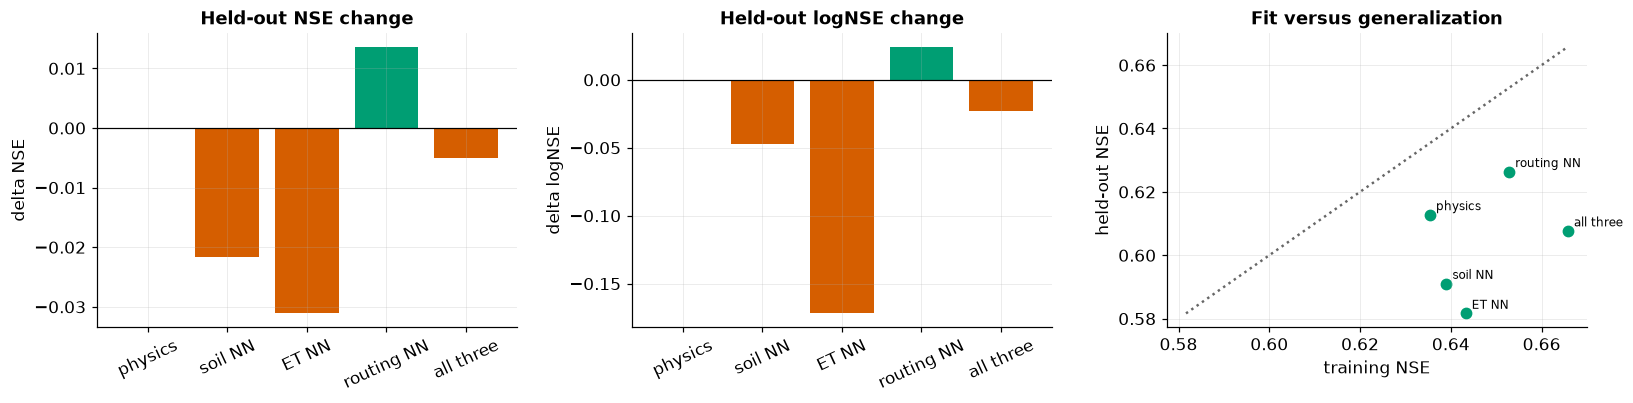

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
names = list(results)
base_nse = results["physics"]["test"]["NSE"]
base_log = results["physics"]["test"]["logNSE"]

for ax, key, base, title in [
    (axes[0], "NSE", base_nse, "Held-out NSE change"),
    (axes[1], "logNSE", base_log, "Held-out logNSE change"),
]:
    vals = [results[n]["test"][key] - base for n in names]
    colors = [COLORS["physics"] if n == "physics" else
              (COLORS["hybrid"] if v > 0 else COLORS["ml"]) for n, v in zip(names, vals)]
    ax.bar(names, vals, color=colors)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel(f"delta {key}")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)

train_scores = [results[n]["train"] for n in names]
test_scores = [results[n]["test"]["NSE"] for n in names]
axes[2].scatter(train_scores, test_scores, color=COLORS["hybrid"], s=45)
for name, xval, yval in zip(names, train_scores, test_scores):
    axes[2].annotate(name, (xval, yval), xytext=(4, 3), textcoords="offset points", fontsize=8)
lo = min(train_scores + test_scores)
hi = max(train_scores + test_scores)
axes[2].plot([lo, hi], [lo, hi], ":", color="0.4")
axes[2].set(xlabel="training NSE", ylabel="held-out NSE", title="Fit versus generalization")

plt.tight_layout()
plt.show()


Validation and test do not rank the variants in the same order. The routing
closure is the only one that improves held-out NSE, while the all-three model
has the best training fit. Differences of a few hundredths are too small to
rank architectures from one split.

Metrics also emphasize different behavior. NSE favors routing; KGE favors the
all-three model; log-NSE penalizes the ET closure most strongly. Pair aggregate
scores with process-specific diagnostics
{cite}`lamichhane2025dynamic,kalauni2025hybrid`.

## 4. Learned functions

The one-dimensional closures can be plotted directly against the relations
they replace.


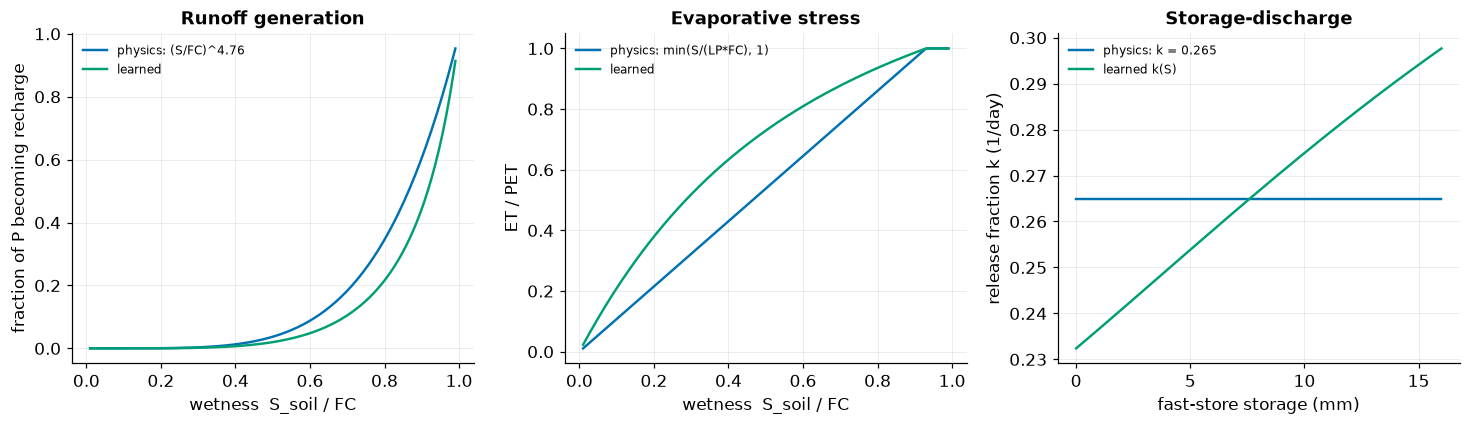

In [13]:
w = torch.linspace(0.01, 0.99, 200)
s = torch.linspace(0.0, 16.0, 200)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

with torch.no_grad():
    # --- runoff generation
    th = results["soil NN"]["theta"]
    base = torch.clamp(w, 1e-4, 1 - 1e-4) ** th[0, 1]
    learned = torch.sigmoid(logit(base) + results["soil NN"]["nets"]["soil"](w.unsqueeze(-1)).squeeze(-1))
    axes[0].plot(w, base, color=COLORS["physics"], label=f"physics: (S/FC)^{float(th[0,1]):.2f}")
    axes[0].plot(w, learned, color=COLORS["hybrid"], label="learned")
    axes[0].set_xlabel("wetness  S_soil / FC"); axes[0].set_ylabel("fraction of P becoming recharge")
    axes[0].set_title("Runoff generation")

    # --- evaporative stress
    th = results["ET NN"]["theta"]
    base = torch.clamp(w * th[0, 0] / (th[0, 2] * th[0, 0]), 1e-4, 1 - 1e-4)
    learned = torch.sigmoid(logit(base) + results["ET NN"]["nets"]["et"](w.unsqueeze(-1)).squeeze(-1))
    axes[1].plot(w, base, color=COLORS["physics"], label=f"physics: min(S/(LP*FC), 1)")
    axes[1].plot(w, learned, color=COLORS["hybrid"], label="learned")
    axes[1].set_xlabel("wetness  S_soil / FC"); axes[1].set_ylabel("ET / PET")
    axes[1].set_title("Evaporative stress")

    # --- storage-discharge
    th = results["routing NN"]["theta"]
    learned = torch.sigmoid(logit(th[0, 3])
                            + results["routing NN"]["nets"]["route"]((s / S_REF).unsqueeze(-1)).squeeze(-1))
    axes[2].plot(s, np.full_like(s, float(th[0, 3])), color=COLORS["physics"],
                 label=f"physics: k = {float(th[0,3]):.3f}")
    axes[2].plot(s, learned, color=COLORS["hybrid"], label="learned k(S)")
    axes[2].set_xlabel("fast-store storage (mm)"); axes[2].set_ylabel("release fraction k (1/day)")
    axes[2].set_title("Storage-discharge")

for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The runoff-generation closure delays recharge at moderate wetness and turns up
near saturation. The ET closure maintains near-potential evaporation farther
into drying, but reduces held-out low-flow skill. The routing closure adds a
small, monotone increase in release fraction with storage and is the only
variant that improves all held-out variance-based metrics.

These curves are hypotheses about this basin, not recovered laws. Their form
and ranking depend on the objective function.

## 5. Limitations

- A closure may compensate for solver, forcing, or observation error.
- Different seeds can produce similar scores with different functions.
- One basin and one temporal split do not establish a general structural error.
- A plotted function is not yet a transferable equation. Sparse recovery from
  learned closures remains unstable {cite}`rackauckas2021universal`.

## Your turn

1. Retrain the routing closure with seeds 1, 2, and 3. Compare variation in
   test NSE with variation in the shape of $k(S)$.
2. Replace the training loss with equal weights on NSE and log-NSE, then rerun
   the variants. Check whether the ET relation or model ranking changes.

:::{dropdown} Suggested interpretation
Metric differences of 0.01-0.02 are often comparable to seed variation. The
monotone shape of the routing relation is usually more stable than its exact
height. Adding log-NSE penalizes the low-flow damage from the ET closure and
can change the ranking. Closure placement is therefore conditional on the
objective as well as the model structure.
:::

## Takeaways

- Controlled closure placement can localize model sensitivity to structural
  changes, but the result depends on the loss and test metric.
- The routing closure generalized best here; the least constrained model had
  the best training fit but not the best held-out score.
- Report score variation across seeds and the learned function, not a single
  small metric improvement.

## Where next

Notebook `06_practical_guide` covers training diagnostics; notebook
`07_open_questions` examines interpretation and symbolic recovery.

## References

```{bibliography}
:filter: docname in docnames
```
